Amazon Fine Food Reviews: EDA
Introduction
Dataset statistics
Number of reviews 	568,454
Number of users 	256,059
Number of products 	74,258
Users with > 50 reviews 	260
Median no. of words per review 	56
Timespan 	Oct 1999 - Oct 2012

Data Fields Explanation

The Amazon Fine Food Reviews dataset consists of 568,454 food reviews. This dataset consists of a single CSV file, Reviews.csv. The columns in the table are:

    Id - Unique row number
    ProductId - unique identifier for the product
    UserId - unqiue identifier for the user
    ProfileName
    HelpfulnessNumerator - number of users who found the review helpful
    HelpfulnessDenominator - number of users who indicated whether they found the review helpful
    Score - rating between 1 and 5
    Time - timestamp for the review
    Summary - brief summary of the review
    Text - text of the review

#from IPython.display import Image
#Image(filename='AmazonReview.png')
Objective
Analysing the data & plot the required graphs to show that these conclusions are true:

a. Positive reviews are very common.
b. Positive reviews are shorter.
c. Longer reviews are more helpful.
d. Despite being more common and shorter, positive reviews are found more helpful.
e. Frequent reviewers are more discerning in their ratings, write longer reviews, and write more helpful reviews
Note: This notebook is highly inspired from the Exploratory visualization of Amazon fine food reviews by Rob Castellano.



In [22]:
# Data handling
import pandas as pd
import numpy as np

# Text preprocessing
import re
import nltk

# Download stopwords
nltk.download('stopwords')

from nltk.corpus import stopwords

# Vectorization
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Train test split
from sklearn.model_selection import train_test_split

# Evaluation
from sklearn import metrics

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shubhangi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [23]:
#Loading the Data
#Let's import pandas to read the csv file.

import pandas as pd
df = pd.read_csv("Reviews.csv")

In [24]:
#Printing first 5 columns from our data frame
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1.0,1.0,5.0,1.303862e+09,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0.0,0.0,1.0,1.346976e+09,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1.0,1.0,4.0,1.219018e+09,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3.0,3.0,2.0,1.307923e+09,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0.0,0.0,5.0,1.350778e+09,Great taffy,Great taffy at a great price. There was a wid...


In [25]:
#Observing the lables of each column
print(df.keys())

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


In [26]:
#Observing the shape of our data frame.
df.shape
# Note: We have 10 features and 568454 data points.

(240754, 10)

In [27]:
df = df.dropna()

In [28]:
#Lets check for missing values
df.info()
#Observe that there are some missing values in 'PROFILENAME' & 'SUMMARY' column.

<class 'pandas.core.frame.DataFrame'>
Index: 240730 entries, 0 to 240752
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Id                      240730 non-null  int64  
 1   ProductId               240730 non-null  object 
 2   UserId                  240730 non-null  object 
 3   ProfileName             240730 non-null  object 
 4   HelpfulnessNumerator    240730 non-null  float64
 5   HelpfulnessDenominator  240730 non-null  float64
 6   Score                   240730 non-null  float64
 7   Time                    240730 non-null  float64
 8   Summary                 240730 non-null  object 
 9   Text                    240730 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 20.2+ MB


In [29]:
df.describe()
#Observe that more than 75% of our data is belonging to positive /
#class, i.e. we have imbalanced dataset.

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,240730.000000,240730.000000,240730.000000,240730.00000,2.407300e+05
mean,120377.461422,1.727977,2.214066,4.17061,1.295854e+09
std,69499.830671,7.533882,8.193425,1.31333,4.798414e+07
min,1.000000,0.000000,0.000000,1.00000,9.393408e+08
25%,60190.250000,0.000000,0.000000,4.00000,1.270426e+09
50%,120377.500000,0.000000,1.000000,5.00000,1.310515e+09
75%,180566.750000,2.000000,2.000000,5.00000,1.332461e+09
max,240753.000000,866.000000,923.000000,5.00000,1.351210e+09


In [30]:
#Lets do the value count on 'Scores'.
df.Score.value_counts()


Score
5.0    152140
4.0     34808
1.0     22221
3.0     18716
2.0     12845
Name: count, dtype: int64

## Exploratory Data Analysis
Till now we saw that 5-star reviews constitute a large proportion (64%) of all reviews. The next most prevalent rating is 4-stars(14%), followed by 1-star (9%), 3-star (8%), and finally 2-star reviews (5%).
Note that we have 10 features and 568454 data points. There are some missing values in 'PROFILENAME' & 'SUMMARY' column. More than 75% of our data is belonging to positive class(Score=4,5), i.e. we have imbalanced dataset.



C:\Users\Shubhangi\AppData\Local\Temp\ipykernel_1780\630871930.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Score', data=df, palette='RdBu')


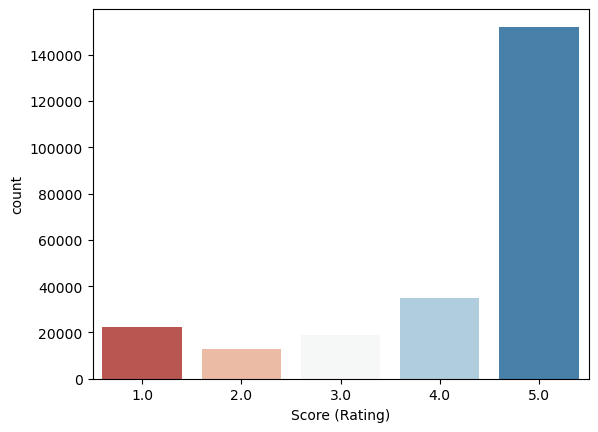

In [31]:
#Importing Seaborn and Matplotlib for graphical effects.
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.countplot(x='Score', data=df, palette='RdBu')
plt.xlabel('Score (Rating)')
plt.show()

## Creating a new dataframe

## STEP 5: CONVERT SCORE → SENTIMENT
## 👉 Logic:
## Score < 3 → Negative (0)
## Score > 3 → Positive (1)
## Score = 3 → Neutral (removed later)

In [32]:
# Convert ratings into sentiments

def convert_sentiment(score):

    if score < 3:
        return 0      # Negative

    elif score == 3:
        return 1      # Neutral

    else:
        return 2      # Positive

df['Score'] = df['Score'].apply(convert_sentiment)

In [33]:
print(df['Score'].value_counts())

Score
2    186948
0     35066
1     18716
Name: count, dtype: int64


In [34]:
# 1. Sentiment Distribution Graph
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Score', data=df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.savefig("static/sentiment_chart.png")

plt.close()

In [35]:
# Input feature
X = df['Text']

# Target/output
y = df['Score']

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## TEXT PREPROCESSING

In [37]:
X_train = X_train.str.lower()
X_test = X_test.str.lower()

In [38]:
import re

def striphtml(data):
    return re.sub(r'<.*?>', '', str(data))

X_train = X_train.apply(striphtml)
X_test = X_test.apply(striphtml)

## 3. Remove special characters

In [39]:
X_train = X_train.apply(lambda x: re.sub(r'[^A-Za-z\s]', '', x))

X_test = X_test.apply(lambda x: re.sub(r'[^A-Za-z\s]', '', x))

## 4. Remove stopwords

In [40]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Keep "not"
stop_words.discard("not")

In [43]:
def remove_stopwords(text):

    words = text.split()

    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(filtered_words)

In [44]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [45]:
#STEP 1 — Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer

#Create tokenizer:

tokenizer = Tokenizer(num_words=5000)

#Fit tokenizer on training text:

tokenizer.fit_on_texts(X_train)

In [46]:
#STEP 2 — Convert Text into Sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)

X_test_seq = tokenizer.texts_to_sequences(X_test)

In [48]:
# STEP 3 — Padding

# Import:

from tensorflow.keras.preprocessing.sequence import pad_sequences

#Apply padding:

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=200,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=200,
    padding='post'
)

In [49]:
#STEP 4 — Convert Labels

#Import:

from tensorflow.keras.utils import to_categorical

#Convert output labels:

y_train_cat = to_categorical(y_train, num_classes=3)

y_test_cat = to_categorical(y_test, num_classes=3)

In [50]:
#STEP 5 — Build LSTM Model

#Import:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

#Create model:

model = Sequential()

#Add Embedding layer:

model.add(
    Embedding(
        input_dim=5000,
        output_dim=128,
        input_length=200
    )
)

#Add LSTM layer:

model.add(LSTM(64))

# Add Output layer:

model.add(Dense(3, activation='softmax'))

C:\Users\Shubhangi\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [51]:
# STEP 6 — Compile Model
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [52]:
# STEP 7 — Train Model
model.fit(
    X_train_pad,
    y_train_cat,
    epochs=5,
    batch_size=128,
    validation_data=(X_test_pad, y_test_cat)
)

Epoch 1/5
1505/1505 ━━━━━━━━━━━━━━━━━━━━ 603s 399ms/step - accuracy: 0.7780 - loss: 0.6716 - val_accuracy: 0.7767 - val_loss: 0.6731
Epoch 2/5
1505/1505 ━━━━━━━━━━━━━━━━━━━━ 563s 374ms/step - accuracy: 0.8047 - loss: 0.5683 - val_accuracy: 0.8557 - val_loss: 0.3913
Epoch 3/5
1505/1505 ━━━━━━━━━━━━━━━━━━━━ 835s 516ms/step - accuracy: 0.8732 - loss: 0.3425 - val_accuracy: 0.8795 - val_loss: 0.3248
Epoch 4/5
1505/1505 ━━━━━━━━━━━━━━━━━━━━ 1134s 754ms/step - accuracy: 0.8940 - loss: 0.2836 - val_accuracy: 0.8876 - val_loss: 0.3081
Epoch 5/5
1505/1505 ━━━━━━━━━━━━━━━━━━━━ 2834s 2s/step - accuracy: 0.9094 - loss: 0.2475 - val_accuracy: 0.8886 - val_loss: 0.3005


In [53]:
#STEP 8 — Check Accuracy
loss, accuracy = model.evaluate(
    X_test_pad,
    y_test_cat
)

print("Accuracy:", accuracy)

1505/1505 ━━━━━━━━━━━━━━━━━━━━ 117s 78ms/step - accuracy: 0.8886 - loss: 0.3005
Accuracy: 0.8886096477508545


In [54]:
# STEP 9 — Save Model
model.save("lstm_model.h5")

# Save tokenizer:

import pickle

pickle.dump(
    tokenizer,
    open("tokenizer.pkl", "wb")
)